In [18]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from scipy.special import expit  # sigmoid
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score
)
from sklearn.model_selection import train_test_split

In [19]:
df = pd.read_csv('../data/processed_data.csv')
print("Dataset shape:", df.shape)

# Separate features and target
y_raw = df['Attrition'].values
X = df.drop(columns=['Attrition']).values
y = (y_raw == y_raw.max()).astype(int)
feature_names = df.drop(columns=['Attrition']).columns.tolist()

print(f"\nFeatures shape: {X.shape}")
print(f"Original class distribution (real data):")
print(f"  No Attrition (0): {np.sum(y == 0)}")
print(f"  Attrition    (1): {np.sum(y == 1)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")
print(f"Test class distribution (real, untouched):")
print(f"  No Attrition (0): {np.sum(y_test == 0)}")
print(f"  Attrition    (1): {np.sum(y_test == 1)}")

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print(f"\nAfter SMOTE — Train: {X_train.shape[0]} samples")
print(f"  No Attrition (0): {np.sum(y_train == 0)}")
print(f"  Attrition    (1): {np.sum(y_train_resampled == 1)}")

Dataset shape: (1470, 37)

Features shape: (1470, 36)
Original class distribution (real data):
  No Attrition (0): 1232
  Attrition    (1): 238

Train: 1176 samples | Test: 294 samples
Test class distribution (real, untouched):
  No Attrition (0): 246
  Attrition    (1): 48

After SMOTE — Train: 1176 samples
  No Attrition (0): 986
  Attrition    (1): 986


In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier

class RandomForestFromScratch:
    
    def __init__(
        self,
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42
    ):
        
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        
        self.trees = []
        np.random.seed(random_state)
    
    def bootstrap_sample(self, X, y):
        
        n_samples = X.shape[0]
        
        indices = np.random.choice(
            n_samples,
            n_samples,
            replace=True
        )
        
        return X[indices], y[indices]
    

    def fit(self, X, y):
        
        self.trees = []
        
        for i in range(self.n_estimators):
            
            # 1 bootstrap sampling
            X_sample, y_sample = self.bootstrap_sample(X, y)
            
            # 2 create tree
            tree = DecisionTreeClassifier(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                min_samples_leaf=self.min_samples_leaf
            )
            
            # 3 train tree
            tree.fit(X_sample, y_sample)
            
            self.trees.append(tree)
    
    def predict_proba(self, X):
        
        tree_probs = []
        
        for tree in self.trees:
            
            prob = tree.predict_proba(X)
            tree_probs.append(prob)
        
        tree_probs = np.array(tree_probs)
        
        # average probability
        avg_prob = np.mean(tree_probs, axis=0)
        
        return avg_prob
    
    def predict(self, X, threshold=0.5):
        
        prob = self.predict_proba(X)[:,1]
        
        return (prob >= threshold).astype(int)

In [21]:
rf_model = RandomForestFromScratch(
    n_estimators=200,
    max_depth=4,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

In [22]:
rf_model.fit(X_train_resampled, y_train_resampled)
y_prob = rf_model.predict_proba(X_test)[:,1]
y_pred = (y_prob >= 0.25).astype(int)
y_pred = rf_model.predict(X_test, threshold=0.25)


Accuracy: 0.6020408163265306
ROC AUC: 0.7533875338753387
specificity: 0.5772357723577236

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.58      0.71       246
           1       0.25      0.73      0.37        48

    accuracy                           0.60       294
   macro avg       0.58      0.65      0.54       294
weighted avg       0.81      0.60      0.65       294


Confusion Matrix:
[[142 104]
 [ 13  35]]


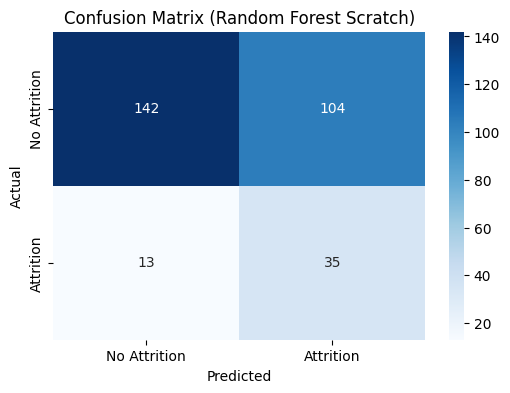

In [23]:
# -------------------------
# Evaluation
# -------------------------

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("specificity:", confusion_matrix(y_test, y_pred)[0, 0] / np.sum(confusion_matrix(y_test, y_pred)[0]))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Attrition", "Attrition"],
            yticklabels=["No Attrition", "Attrition"])
plt.title("Confusion Matrix (Random Forest Scratch)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [24]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [25]:
from sklearn.metrics import roc_auc_score
from itertools import product

best_score = 0
best_params = None
best_model = None

for n_estimators, max_depth, min_split, min_leaf in product(
        param_grid["n_estimators"],
        param_grid["max_depth"],
        param_grid["min_samples_split"],
        param_grid["min_samples_leaf"]
):

    print("\nTesting:")
    print(n_estimators, max_depth, min_split, min_leaf)

    model = RandomForestFromScratch(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_split,
        min_samples_leaf=min_leaf,
        random_state=42
    )

    # train
    model.fit(X_train_resampled, y_train_resampled)

    # predict probability
    y_prob = model.predict_proba(X_test)[:,1]

    # evaluate
    score = roc_auc_score(y_test, y_prob)

    print("ROC-AUC:", score)

    if score > best_score:
        best_score = score
        best_params = {
            "n_estimators": n_estimators,
            "max_depth": max_depth,
            "min_samples_split": min_split,
            "min_samples_leaf": min_leaf
        }
        best_model = model

print("\n===== BEST MODEL =====")
print("Best ROC-AUC:", best_score)
print("Best Params:", best_params)


Testing:
100 None 2 1
ROC-AUC: 0.7362804878048781

Testing:
100 None 2 2
ROC-AUC: 0.7482638888888888

Testing:
100 None 5 1
ROC-AUC: 0.7563939701897019

Testing:
100 None 5 2
ROC-AUC: 0.7540226964769647

Testing:
100 10 2 1
ROC-AUC: 0.7571985094850948

Testing:
100 10 2 2
ROC-AUC: 0.7545731707317074

Testing:
100 10 5 1
ROC-AUC: 0.7604166666666666

Testing:
100 10 5 2
ROC-AUC: 0.7531334688346883

Testing:
100 20 2 1
ROC-AUC: 0.736111111111111

Testing:
100 20 2 2
ROC-AUC: 0.7485602981029811

Testing:
100 20 5 1
ROC-AUC: 0.756224593495935

Testing:
100 20 5 2
ROC-AUC: 0.7529640921409214

Testing:
200 None 2 1
ROC-AUC: 0.7485179539295392

Testing:
200 None 2 2
ROC-AUC: 0.7525829945799458

Testing:
200 None 5 1
ROC-AUC: 0.7577489837398375

Testing:
200 None 5 2
ROC-AUC: 0.7571561653116532

Testing:
200 10 2 1
ROC-AUC: 0.7594850948509486

Testing:
200 10 2 2
ROC-AUC: 0.7580453929539295

Testing:
200 10 5 1
ROC-AUC: 0.7602472899728997

Testing:
200 10 5 2
ROC-AUC: 0.7578760162601627

Testi

In [26]:
rf_model = best_model

y_prob = rf_model.predict_proba(X_test)[:,1]
y_pred = (y_prob >= 0.25).astype(int)

In [27]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print(cm)

Accuracy: 0.7278911564625851
              precision    recall  f1-score   support

           0       0.92      0.74      0.82       246
           1       0.33      0.65      0.44        48

    accuracy                           0.73       294
   macro avg       0.62      0.69      0.63       294
weighted avg       0.82      0.73      0.76       294

[[183  63]
 [ 17  31]]


In [28]:
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns

# -------------------------
# 5) Random Forest Model
# -------------------------
rf_model = RandomForestClassifier(
    n_estimators=200,      # จำนวนต้นไม้
    max_depth=None,        # ปล่อยให้ tree โตเต็ม
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

# Train
rf_model.fit(X_train_resampled, y_train_resampled)

# -------------------------
# 6) Prediction
# -------------------------
y_prob = rf_model.predict_proba(X_test)[:,1]
y_pred = (y_prob >= 0.25).astype(int)

# -------------------------
# 7) Evaluation
# -------------------------
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("\n===== Random Forest Results =====")
print("Accuracy :", accuracy)
print("ROC AUC  :", roc_auc)
print("specificity:", confusion_matrix(y_test, y_pred)[0, 0] / np.sum(confusion_matrix(y_test, y_pred)[0]))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix")
print(cm)


===== Random Forest Results =====
Accuracy : 0.6802721088435374
ROC AUC  : 0.7895918021680217
specificity: 0.6747967479674797

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.67      0.78       246
           1       0.30      0.71      0.42        48

    accuracy                           0.68       294
   macro avg       0.61      0.69      0.60       294
weighted avg       0.82      0.68      0.72       294


Confusion Matrix
[[166  80]
 [ 14  34]]


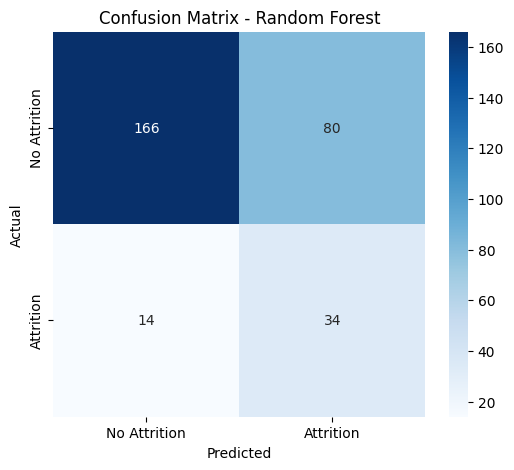

In [29]:
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["No Attrition","Attrition"],
    yticklabels=["No Attrition","Attrition"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

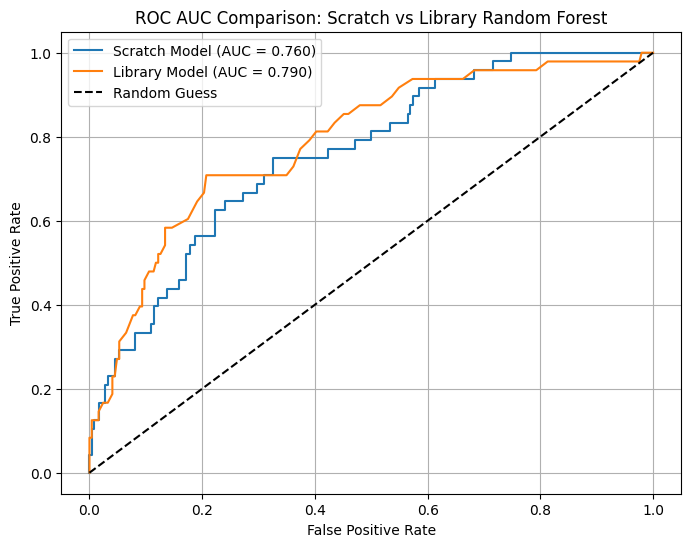

In [30]:
from sklearn.metrics import roc_curve

# ROC for scratch model
y_prob_scratch = best_model.predict_proba(X_test)[:, 1]
fpr_scratch, tpr_scratch, _ = roc_curve(y_test, y_prob_scratch)
auc_scratch = roc_auc_score(y_test, y_prob_scratch)

# ROC for library model
y_prob_lib = rf_model.predict_proba(X_test)[:, 1]
fpr_lib, tpr_lib, _ = roc_curve(y_test, y_prob_lib)
auc_lib = roc_auc_score(y_test, y_prob_lib)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_scratch, tpr_scratch, label=f'Scratch Model (AUC = {auc_scratch:.3f})')
plt.plot(fpr_lib, tpr_lib, label=f'Library Model (AUC = {auc_lib:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC AUC Comparison: Scratch vs Library Random Forest')
plt.legend()
plt.grid(True)
plt.show()